# Vijay Hanumandla
# 23102C0071
# AML : Spectral Clustering for a graph
# EXP : 06

Number of nodes: 34
Number of edges: 78


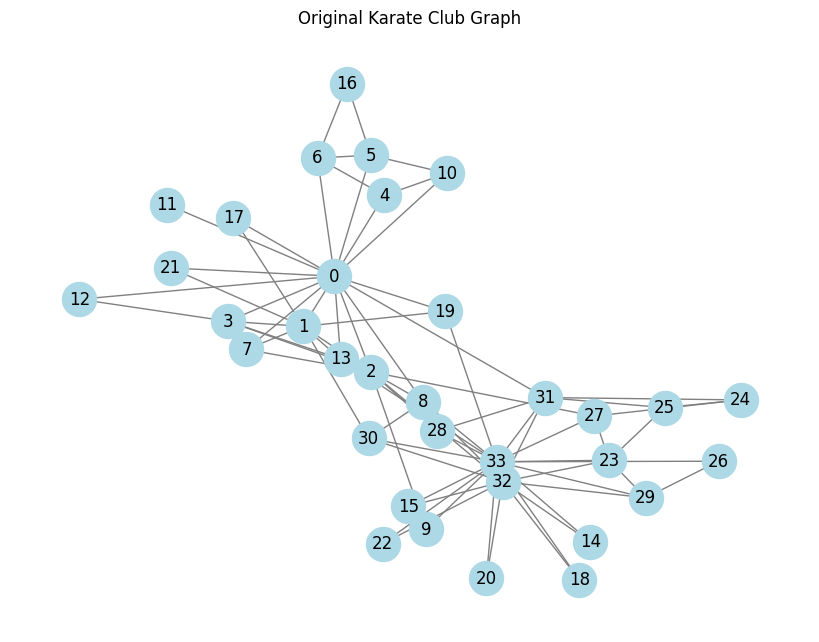

In [1]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create Karate Club graph
G = nx.karate_club_graph()

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Display the original graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=600,
    edge_color="gray"
)
plt.title("Original Karate Club Graph")
plt.show()

# Construct the adjacency matrix and graph Laplacian

In [2]:
# Convert graph into adjacency matrix
A = nx.to_numpy_array(G)

print("Adjacency Matrix:")
print(A)

# Degree matrix
degrees = np.sum(A, axis=1)
D = np.diag(degrees)

# Unnormalized Graph Laplacian
L = D - A

print("\nDegree Matrix:")
print(D)

print("\nGraph Laplacian Matrix:")
print(L)

Adjacency Matrix:
[[0. 4. 5. ... 2. 0. 0.]
 [4. 0. 6. ... 0. 0. 0.]
 [5. 6. 0. ... 0. 2. 0.]
 ...
 [2. 0. 0. ... 0. 4. 4.]
 [0. 0. 2. ... 4. 0. 5.]
 [0. 0. 0. ... 4. 5. 0.]]

Degree Matrix:
[[42.  0.  0. ...  0.  0.  0.]
 [ 0. 29.  0. ...  0.  0.  0.]
 [ 0.  0. 33. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... 21.  0.  0.]
 [ 0.  0.  0. ...  0. 38.  0.]
 [ 0.  0.  0. ...  0.  0. 48.]]

Graph Laplacian Matrix:
[[42. -4. -5. ... -2.  0.  0.]
 [-4. 29. -6. ...  0.  0.  0.]
 [-5. -6. 33. ...  0. -2.  0.]
 ...
 [-2.  0.  0. ... 21. -4. -4.]
 [ 0.  0. -2. ... -4. 38. -5.]
 [ 0.  0.  0. ... -4. -5. 48.]]


# Compute eigenvectors and perform Spectral Clustering

In [3]:
# Compute eigenvalues and eigenvectors of the Laplacian
eigenvalues, eigenvectors = np.linalg.eigh(L)

print("Eigenvalues:")
print(np.round(eigenvalues, 4))

# Number of clusters
k = 2

# Select eigenvectors corresponding to the k smallest eigenvalues
X = eigenvectors[:, :k]

print("\nSelected Eigenvectors:")
print(np.round(X, 4))

# Apply K-Means on the selected eigenvectors
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("\nCluster Labels:")
for node, label in enumerate(labels):
    print(f"Node {node}: Cluster {label}")

Eigenvalues:
[-0.      1.1871  2.3943  2.9318  2.9683  3.061   3.1213  3.7061  3.8009
  4.1616  4.5447  4.6973  4.9782  5.1686  5.5948  6.4461  6.9779  9.181
 10.0107 10.2218 11.8744 12.0754 14.3814 14.8886 17.0338 19.3238 21.3587
 22.785  25.5555 29.6884 37.9928 41.8329 45.9908 52.0653]

Selected Eigenvectors:
[[-0.1715  0.1233]
 [-0.1715  0.058 ]
 [-0.1715  0.0137]
 [-0.1715  0.0745]
 [-0.1715  0.2673]
 [-0.1715  0.2988]
 [-0.1715  0.2974]
 [-0.1715  0.0641]
 [-0.1715 -0.053 ]
 [-0.1715 -0.1293]
 [-0.1715  0.2855]
 [-0.1715  0.2041]
 [-0.1715  0.1232]
 [-0.1715  0.0349]
 [-0.1715 -0.1716]
 [-0.1715 -0.1552]
 [-0.1715  0.3717]
 [-0.1715  0.168 ]
 [-0.1715 -0.2115]
 [-0.1715  0.0626]
 [-0.1715 -0.1885]
 [-0.1715  0.1289]
 [-0.1715 -0.1686]
 [-0.1715 -0.148 ]
 [-0.1715 -0.1576]
 [-0.1715 -0.1463]
 [-0.1715 -0.1925]
 [-0.1715 -0.1298]
 [-0.1715 -0.0945]
 [-0.1715 -0.1696]
 [-0.1715 -0.0837]
 [-0.1715 -0.1171]
 [-0.1715 -0.1354]
 [-0.1715 -0.124 ]]

Cluster Labels:
Node 0: Cluster 0
Node 

# Visualize the spectral clusters and calculate performance

Silhouette Score: 0.6938


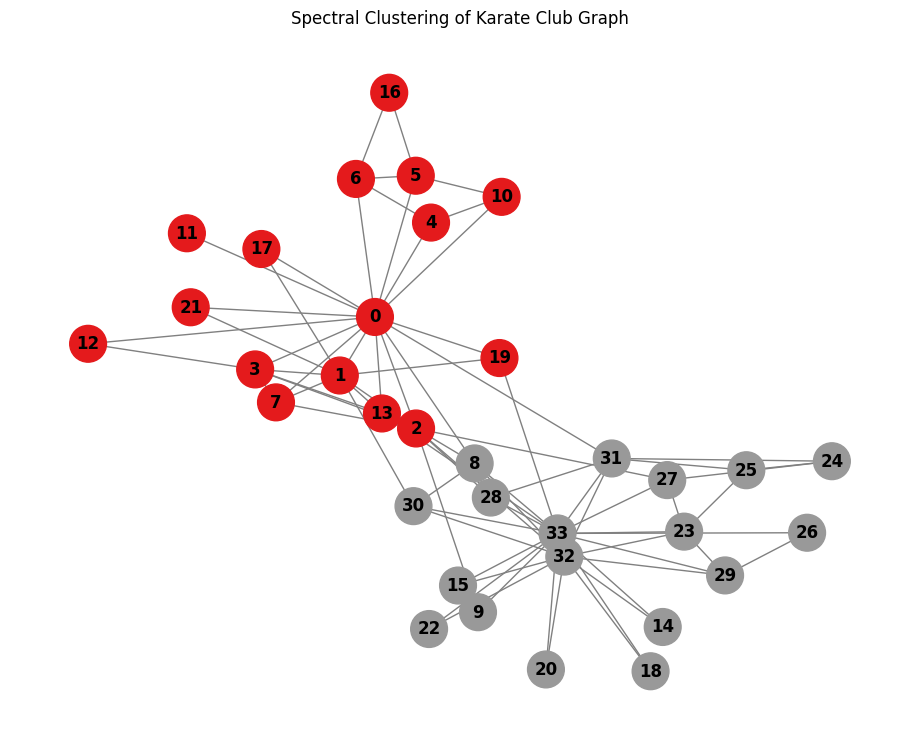

Cluster 0: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
Cluster 1: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [4]:
# Calculate silhouette score
sil_score = silhouette_score(X, labels)

print("Silhouette Score:", round(sil_score, 4))

# Visualize clusters
plt.figure(figsize=(9, 7))

pos = nx.spring_layout(G, seed=42)

# Draw graph using cluster labels as node colors
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=labels,
    cmap=plt.cm.Set1,
    node_size=700,
    edge_color="gray",
    font_weight="bold"
)

plt.title("Spectral Clustering of Karate Club Graph")
plt.show()

# Display nodes belonging to each cluster
for cluster in range(k):
    nodes = [node for node, label in enumerate(labels) if label == cluster]
    print(f"Cluster {cluster}: {nodes}")

# Conclusion:
Spectral Clustering was successfully performed on the Karate Club graph.
The graph Laplacian was constructed and its eigenvectors were used for
clustering. K-Means was applied to the selected eigenvectors to divide
the nodes into two clusters. The resulting visualization shows the
identified communities, and the silhouette score of 0.6938 indicates
reasonably good cluster separation.